In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [6]:
from sklearn.datasets import fetch_california_housing

In [8]:
fetch_california_housing()

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [10]:
df = fetch_california_housing()

In [12]:
dataset = pd.DataFrame(df.data)

In [14]:
dataset.columns = df.feature_names

In [16]:
X = dataset 
y = df.target

In [115]:
from sklearn.model_selection import train_test_split
X_train,X_test ,y_train, y_test = train_test_split(
    X, y, test_size = 0.30 ,random_state = 42) 

In [117]:
from sklearn.preprocessing import StandardScaler

In [119]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [121]:
X_train = scaler.transform(X_train)

C:\Users\arvin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [123]:
X_test = scaler.transform(X_test)

In [125]:
from sklearn.linear_model import LinearRegression

In [129]:
from sklearn.model_selection import cross_val_score

In [131]:
regression = LinearRegression()
regression.fit(X_train , y_train)

LinearRegression()

In [133]:
mse = cross_val_score(regression , X_train , y_train , scoring = "neg_mean_squared_error" , cv=5)

In [135]:
np.mean(mse)

-0.526825374635575

In [137]:
reg_pred = regression.predict(X_test)

In [139]:
reg_pred


array([75.39904685, 77.64758448, 81.9468823 , ..., 74.04218911,
       71.25418692, 74.51758511])

In [141]:
import seaborn as sns 

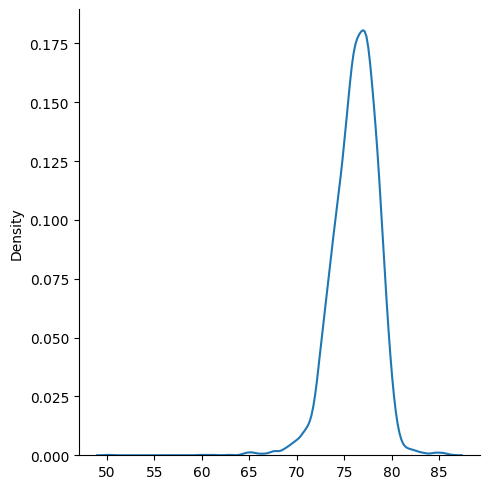

In [143]:
sns.displot(reg_pred-y_test , kind ='kde')

In [147]:
from sklearn.metrics import r2_score

In [150]:
score = r2_score(reg_pred,y_test)

In [152]:
score

-759.6180217573941